In [1]:
from pyspark.sql.functions import count, col, when, broadcast, udf, pandas_udf, rand, monotonically_increasing_id
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql import SparkSession
from pyspark.sql.types import StringType, BooleanType, DoubleType, ArrayType, IntegerType, StructType, StructField
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from pyspark.ml.evaluation import ClusteringEvaluator
import datamol as dm
from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt
import findspark
import hdbscan
import os
import sys

In [ ]:
spark.stop()

In [2]:
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

spark = SparkSession.builder \
    .appName("Molecule Analysis") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .config("spark.memory.fraction", "0.6") \
    .config("spark.memory.storageFraction", "0.3") \
    .config("spark.network.timeout", "1000s") \
    .config("spark.executor.heartbeatInterval", "180s") \
    .config("spark.sql.broadcastTimeout", "1000s") \
    .config("spark.executor.waitTime", "1000s") \
    .getOrCreate()

----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 63577)
Traceback (most recent call last):
  File "C:\Users\User\AppData\Local\Programs\Python\Python310\lib\socketserver.py", line 316, in _handle_request_noblock
    self.process_request(request, client_address)
  File "C:\Users\User\AppData\Local\Programs\Python\Python310\lib\socketserver.py", line 347, in process_request
    self.finish_request(request, client_address)
  File "C:\Users\User\AppData\Local\Programs\Python\Python310\lib\socketserver.py", line 360, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "C:\Users\User\AppData\Local\Programs\Python\Python310\lib\socketserver.py", line 747, in __init__
    self.handle()
  File "c:\Users\User\OneDrive\Рабочий стол\Pharm1\BELKA\venv\lib\site-packages\pyspark\accumulators.py", line 295, in handle
    poll(accum_updates)
  File "c:\Users\User\OneDrive\Рабочий стол\Pharm1\BELKA\venv\lib\site-

In [3]:
filename = "leash-BELKA/train.parquet"
data = spark.read.parquet(filename)

data.printSchema()

data.show(5)

root
 |-- id: long (nullable = true)
 |-- buildingblock1_smiles: string (nullable = true)
 |-- buildingblock2_smiles: string (nullable = true)
 |-- buildingblock3_smiles: string (nullable = true)
 |-- molecule_smiles: string (nullable = true)
 |-- protein_name: string (nullable = true)
 |-- binds: long (nullable = true)

+---+---------------------+---------------------+---------------------+--------------------+------------+-----+
| id|buildingblock1_smiles|buildingblock2_smiles|buildingblock3_smiles|     molecule_smiles|protein_name|binds|
+---+---------------------+---------------------+---------------------+--------------------+------------+-----+
|  0| C#CC[C@@H](CC(=O)...| C#CCOc1ccc(CN)cc1.Cl| Br.Br.NCC1CCCN1c1...|C#CCOc1ccc(CNc2nc...|        BRD4|    0|
|  1| C#CC[C@@H](CC(=O)...| C#CCOc1ccc(CN)cc1.Cl| Br.Br.NCC1CCCN1c1...|C#CCOc1ccc(CNc2nc...|         HSA|    0|
|  2| C#CC[C@@H](CC(=O)...| C#CCOc1ccc(CN)cc1.Cl| Br.Br.NCC1CCCN1c1...|C#CCOc1ccc(CNc2nc...|         sEH|    0|
|  3|

In [15]:
data.groupBy("binds").count().show()

+-----+---------+
|binds|    count|
+-----+---------+
|    0|293656924|
|    1|  1589906|
+-----+---------+



In [17]:
grouped_counts = data.groupBy("protein_name").agg(
    count(when(col('binds') == 1, 1)).alias('positive_count'),
    count(when(col('binds') == 0, 1)).alias('negative_count')
)

grouped_counts = grouped_counts.withColumn(
    "sampling_fraction",
    col("positive_count")/col("negative_count")
)

grouped_counts.show()

+------------+--------------+--------------+--------------------+
|protein_name|positive_count|negative_count|   sampling_fraction|
+------------+--------------+--------------+--------------------+
|         HSA|        408410|      98007200|0.004167142822160...|
|        BRD4|        456964|      97958646|0.004664866437618992|
|         sEH|        724532|      97691078| 0.00741656264659092|
+------------+--------------+--------------+--------------------+



In [19]:
sampling_fraction = broadcast(grouped_counts.select("protein_name", "sampling_fraction"))

data_with_fraction = data.join(sampling_fraction, on = "protein_name", how = "left")

downsampled_data = data_with_fraction.filter(col("binds") == 1).union(
    data_with_fraction.filter(col("binds") == 0).sampleBy(
        col("protein_name"), fractions = dict(sampling_fraction.rdd.collectAsMap()), seed = 42
    )
)

In [21]:
downsampled_data.groupby("binds").count().show()

+-----+-------+
|binds|  count|
+-----+-------+
|    1|1589906|
|    0|1592766|
+-----+-------+



**SMART DOWNSAMPLING**

*Based on descriptors*

*Desctiptors extraction*

In [23]:
data = data.filter(col("protein_name") == "sEH")

In [5]:
sampled_data = data.orderBy(rand()).limit(3000)

In [6]:
del data

Descriptors calculations

In [7]:
desc_schema = StructType([
    StructField("mol_wt", DoubleType(), True),
    StructField("mol_logp", DoubleType(), True),
    StructField("tpsa", DoubleType(), True),
]
)

@pandas_udf(desc_schema)
def calculate_desc(smiles_series: pd.Series) -> pd.DataFrame:

    mols = smiles_series.apply(Chem.MolFromSmiles)
    
    mw = mols.apply(lambda mol: Descriptors.MolWt(mol) if mol else None)
    logp = mols.apply(lambda mol: Descriptors.MolLogP(mol) if mol else None)
    tpsa = mols.apply(lambda mol: Descriptors.TPSA(mol) if mol else None)

    return pd.DataFrame({'mol_wt': mw, 'mol_logp': logp, 'tpsa': tpsa})

In [8]:
sampled_data_with_desc = sampled_data.withColumn("molecule", calculate_desc(col("molecule_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block1", calculate_desc(col("buildingblock1_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block2", calculate_desc(col("buildingblock2_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block3", calculate_desc(col("buildingblock3_smiles")))

In [9]:
selected_columns = [
    "id",
    col("molecule.mol_wt").alias("molecule_mol_wt"),
    col("molecule.mol_logp").alias("molecule_mol_logp"),
    col("molecule.tpsa").alias("molecule_tpsa"),
    col("block1.mol_wt").alias("block1_mol_wt"),
    col("block1.mol_logp").alias("block1_mol_logp"),
    col("block1.tpsa").alias("block1_tpsa"),
    col("block2.mol_wt").alias("block2_mol_wt"),
    col("block2.mol_logp").alias("block2_mol_logp"),
    col("block2.tpsa").alias("block2_tpsa"),
    col("block3.mol_wt").alias("block3_mol_wt"),
    col("block3.mol_logp").alias("block3_mol_logp"),
    col("block3.tpsa").alias("block3_tpsa"),
]

flattened_data = sampled_data_with_desc.select(*selected_columns)

In [10]:
del sampled_data_with_desc

In [11]:
desc_columns = [col_name for col_name in flattened_data.columns if col_name != "id"]

assembler = VectorAssembler(inputCols=desc_columns, outputCol="features")
sampled_data_with_features = assembler.transform(flattened_data)

In [12]:
del flattened_data

In [13]:
sampled_data_with_features = sampled_data_with_features.repartition(200)

In [14]:
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(sampled_data_with_features)
scaled_data = scaler_model.transform(sampled_data_with_features)

In [28]:
pca = PCA(k=10, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(scaled_data)

In [29]:
explained_variance = pca_model.explainedVariance.cumsum()
print(explained_variance)

[0.2546423  0.45757381 0.5868975  0.70957274 0.80925364 0.90119425
 0.94514583 0.96978883 0.99164429 0.99913861]


In [31]:
optimal_k = (explained_variance >= 0.95).argmax() + 1

print(f"Optimal K for PCA: {optimal_k}")

Optimal K for PCA: 8


In [15]:
pca = PCA(k=8, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(scaled_data)
reduced_data = pca_model.transform(scaled_data)

In [16]:
del sampled_data_with_features
del scaled_data

In [17]:
reduced_data = reduced_data.repartition(200)

In [18]:
import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(message)s")
logger = logging.getLogger()

costs = []
ks = range(3, 7, 2)

for k in ks:

    logger.info(f"Starting clustering with k={k}")

    try:
        kmeans = KMeans(k=k, seed=42, featuresCol="pca_features", predictionCol="kmeans_cluster")
        model = kmeans.fit(reduced_data)
        clustered_data = model.transform(reduced_data)
        
        evaluator = ClusteringEvaluator(featuresCol="pca_features", predictionCol="kmeans_cluster", metricName="silhouette")
        silhouette = evaluator.evaluate(clustered_data)
        costs.append(silhouette)
        
        logger.info(f"Silhouette for k={k}: {silhouette}")
        
    except Exception as e:
        logger.error(f"Error during clustering with k={k}: {e}")
    
reduced_data.unpersist() 

2025-01-31 17:05:58,701 - Starting clustering with k=3
2025-01-31 17:31:04,732 - Silhouette for k=3: 0.22692107312502874
2025-01-31 17:31:04,734 - Starting clustering with k=5
2025-01-31 17:47:22,901 - Silhouette for k=5: 0.19838008209311775


DataFrame[id: bigint, molecule_mol_wt: double, molecule_mol_logp: double, molecule_tpsa: double, block1_mol_wt: double, block1_mol_logp: double, block1_tpsa: double, block2_mol_wt: double, block2_mol_logp: double, block2_tpsa: double, block3_mol_wt: double, block3_mol_logp: double, block3_tpsa: double, features: vector, scaled_features: vector, pca_features: vector]

In [20]:
k = 7

logger.info(f"Starting clustering with k={k}")

try:
    kmeans = KMeans(k=k, seed=42, featuresCol="pca_features", predictionCol="kmeans_cluster")
    model = kmeans.fit(reduced_data)
    clustered_data = model.transform(reduced_data)
    
    evaluator = ClusteringEvaluator(featuresCol="pca_features", predictionCol="kmeans_cluster", metricName="silhouette")
    silhouette = evaluator.evaluate(clustered_data)
    costs.append(silhouette)
    
    logger.info(f"Silhouette for k={k}: {silhouette}")
    
except Exception as e:
    logger.error(f"Error during clustering with k={k}: {e}")

2025-01-31 17:47:37,235 - Starting clustering with k=7
2025-01-31 18:07:09,524 - Silhouette for k=7: 0.1867228967943947


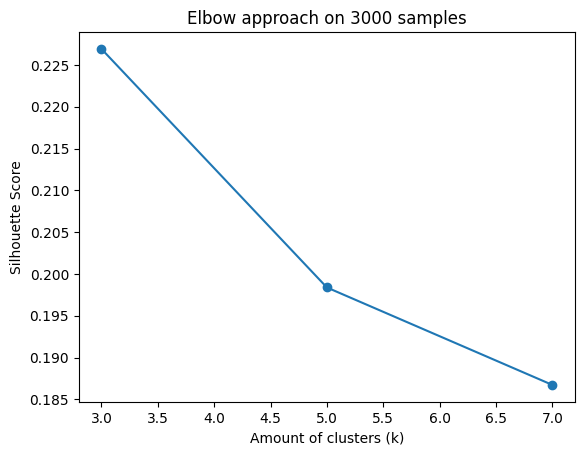

In [21]:
ks = range(3, 8, 2)

plt.plot(ks, costs, marker="o")
plt.xlabel("Amount of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Elbow approach on 3000 samples")
plt.show()

In [4]:
data = data.filter(col("protein_name") == "sEH")
sampled_data = data.orderBy(rand()).limit(100000)

In [5]:
desc_schema = StructType([
    StructField("mol_wt", DoubleType(), True),
    StructField("mol_logp", DoubleType(), True),
    StructField("tpsa", DoubleType(), True),
]
)

@pandas_udf(desc_schema)
def calculate_desc(smiles_series: pd.Series) -> pd.DataFrame:

    mols = smiles_series.apply(Chem.MolFromSmiles)
    
    mw = mols.apply(lambda mol: Descriptors.MolWt(mol) if mol else None)
    logp = mols.apply(lambda mol: Descriptors.MolLogP(mol) if mol else None)
    tpsa = mols.apply(lambda mol: Descriptors.TPSA(mol) if mol else None)

    return pd.DataFrame({'mol_wt': mw, 'mol_logp': logp, 'tpsa': tpsa})
    
sampled_data_with_desc = sampled_data.withColumn("molecule", calculate_desc(col("molecule_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block1", calculate_desc(col("buildingblock1_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block2", calculate_desc(col("buildingblock2_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block3", calculate_desc(col("buildingblock3_smiles")))

In [6]:
selected_columns = [
    "id",
    col("molecule.mol_wt").alias("molecule_mol_wt"),
    col("molecule.mol_logp").alias("molecule_mol_logp"),
    col("molecule.tpsa").alias("molecule_tpsa"),
    col("block1.mol_wt").alias("block1_mol_wt"),
    col("block1.mol_logp").alias("block1_mol_logp"),
    col("block1.tpsa").alias("block1_tpsa"),
    col("block2.mol_wt").alias("block2_mol_wt"),
    col("block2.mol_logp").alias("block2_mol_logp"),
    col("block2.tpsa").alias("block2_tpsa"),
    col("block3.mol_wt").alias("block3_mol_wt"),
    col("block3.mol_logp").alias("block3_mol_logp"),
    col("block3.tpsa").alias("block3_tpsa"),
]

flattened_data = sampled_data_with_desc.select(*selected_columns)

In [7]:
desc_columns = [col_name for col_name in flattened_data.columns if col_name != "id"]

assembler = VectorAssembler(inputCols=desc_columns, outputCol="features")
sampled_data_with_features = assembler.transform(flattened_data)

In [8]:
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(sampled_data_with_features)
scaled_data = scaler_model.transform(sampled_data_with_features)

In [13]:
scaled_data.write.csv("output.csv", header=True, mode="overwrite")

AnalysisException: [UNSUPPORTED_DATA_TYPE_FOR_DATASOURCE] The CSV datasource doesn't support the column `features` of the type "STRUCT<type: TINYINT, size: INT, indices: ARRAY<INT>, values: ARRAY<DOUBLE>>".

In [9]:
pca = PCA(k=8, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(scaled_data)
reduced_data = pca_model.transform(scaled_data)

In [15]:
reduced_data.select("pca_features").write.save("./leash-BELKA/reduced_data.parquet", format="parquet", mode='overwrite')

Py4JJavaError: An error occurred while calling o259.save.
: java.lang.RuntimeException: java.io.FileNotFoundException: java.io.FileNotFoundException: HADOOP_HOME and hadoop.home.dir are unset. -see https://wiki.apache.org/hadoop/WindowsProblems
	at org.apache.hadoop.util.Shell.getWinUtilsPath(Shell.java:735)
	at org.apache.hadoop.util.Shell.getSetPermissionCommand(Shell.java:270)
	at org.apache.hadoop.util.Shell.getSetPermissionCommand(Shell.java:286)
	at org.apache.hadoop.fs.RawLocalFileSystem.setPermission(RawLocalFileSystem.java:978)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkOneDirWithMode(RawLocalFileSystem.java:660)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkdirsWithOptionalPermission(RawLocalFileSystem.java:700)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkdirs(RawLocalFileSystem.java:672)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkdirsWithOptionalPermission(RawLocalFileSystem.java:699)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkdirs(RawLocalFileSystem.java

In [10]:
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(message)s")
logger = logging.getLogger()

costs = []
ks = range(3, 8, 2)

for k in ks:

    logger.info(f"Starting clustering with k={k}")

    try:
        kmeans = KMeans(k=k, seed=42, featuresCol="pca_features", predictionCol="kmeans_cluster")
        model = kmeans.fit(reduced_data)
        clustered_data = model.transform(reduced_data)
        
        wcss = model.summary.trainingCost

        costs.append(wcss)
        
        logger.info(f"WCSS for k={k}: {silhouette}")
        
    except Exception as e:
        logger.error(f"Error during clustering with k={k}: {e}")
    
reduced_data.unpersist() 

2025-02-01 01:16:25,801 - Starting clustering with k=3
2025-02-01 03:59:11,034 - Error during clustering with k=3: name 'silhouette' is not defined
2025-02-01 03:59:11,036 - Starting clustering with k=5
2025-02-01 05:57:32,982 - Error during clustering with k=5: name 'silhouette' is not defined
2025-02-01 05:57:32,993 - Starting clustering with k=7
2025-02-01 07:52:56,540 - Error during clustering with k=7: name 'silhouette' is not defined


DataFrame[id: bigint, molecule_mol_wt: double, molecule_mol_logp: double, molecule_tpsa: double, block1_mol_wt: double, block1_mol_logp: double, block1_tpsa: double, block2_mol_wt: double, block2_mol_logp: double, block2_tpsa: double, block3_mol_wt: double, block3_mol_logp: double, block3_tpsa: double, features: vector, scaled_features: vector, pca_features: vector]

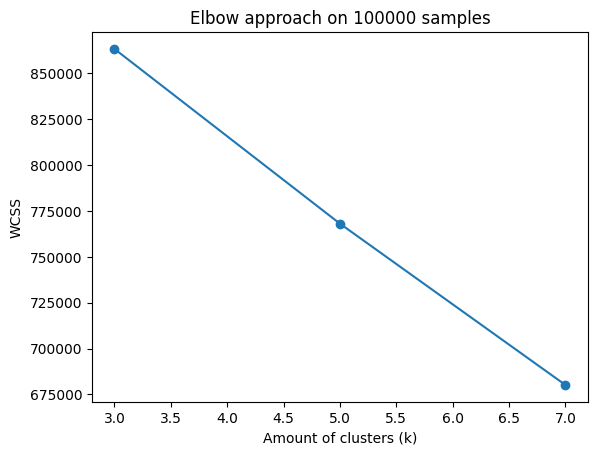

In [12]:
plt.plot(ks, costs, marker="o")
plt.xlabel("Amount of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow approach on 100000 samples")
plt.show()

In [11]:
logging.basicConfig(level = logging.INFO, format = '%(asctime)s - %(message)s')
logger = logging.getLogger()

costs = []
ks = range(11, 21, 3)

for k in ks:

    logger.info(f'Starting clustering with k={k}')

    try:
        kmeans = KMeans(k = k, seed = 42, featuresCol = 'pca_features', predictionCol = 'kmeans_cluster')
        model = kmeans.fit(reduced_data)
        kmeans_clusters = model.transform(reduced_data)

        wcss = model.summary.trainingCost
        costs.append(wcss)
        logger.info(f'WCSS for k={k}: {wcss}')
    except Exception as e:
        logger.error(f'Error during clustering k={k}: {e}')

2025-02-02 11:17:17,965 - Starting clustering with k=11
2025-02-02 13:14:38,777 - WCSS for k=11: 599717.3762609523
2025-02-02 13:14:38,782 - Starting clustering with k=14
2025-02-02 15:47:34,339 - WCSS for k=14: 554116.3442150418
2025-02-02 15:47:34,346 - Starting clustering with k=17
2025-02-02 17:45:31,222 - WCSS for k=17: 510851.2545155097
2025-02-02 17:45:31,223 - Starting clustering with k=20
2025-02-02 19:45:18,576 - WCSS for k=20: 487182.91308276734


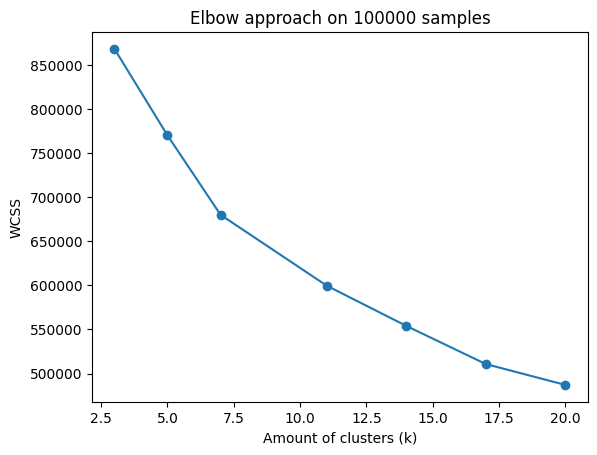

In [16]:
ks = [3,5,7,11,14,17,20]
results_1 = [868000, 770000, 680000, 599717, 554116, 510851, 487182]

plt.plot(ks, results_1, marker="o")
plt.xlabel("Amount of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow approach on 100000 samples")
plt.show()

In [20]:
logging.basicConfig(level = logging.INFO, format = '%(asctime)s - %(message)s')
logger = logging.getLogger()

costs = []
ks = range(23, 30, 3)

for k in ks:

    logger.info(f'Starting clustering with k={k}')

    try:
        kmeans = KMeans(k = k, seed = 42, featuresCol = 'pca_features', predictionCol = 'kmeans_cluster')
        model = kmeans.fit(reduced_data)
        kmeans_clusters = model.transform(reduced_data)

        wcss = model.summary.trainingCost
        costs.append(wcss)
        logger.info(f'WCSS for k={k}: {wcss}')
    except Exception as e:
        logger.error(f'Error during clustering k={k}: {e}')

2025-02-02 23:14:02,050 - Starting clustering with k=23
2025-02-03 01:17:04,130 - WCSS for k=23: 467916.47904761287
2025-02-03 01:17:04,136 - Starting clustering with k=26
2025-02-03 03:17:52,083 - WCSS for k=26: 449381.00037567347
2025-02-03 03:17:52,090 - Starting clustering with k=29
2025-02-03 05:18:52,550 - WCSS for k=29: 433710.86787189386


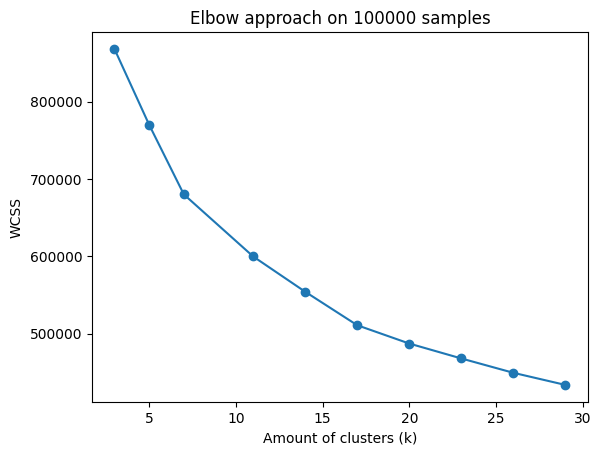

In [22]:
ks = [3,5,7,11,14,17,20, 23, 26, 29]
results_1 = [868000, 770000, 680000, 599717, 554116, 510851, 487182, 467916, 449381, 433710]

plt.plot(ks, results_1, marker="o")
plt.xlabel("Amount of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow approach on 100000 samples")
plt.show()